# OC-SORT Tracker - Optuna Hyperparameter Search Analysis

This notebook analyzes the hyperparameter optimization results for the OC-SORT (Observation-Centric SORT) tracker.
We explore the relationship between hyperparameters (`det_thresh`, `max_age`, `min_hits`, `iou_threshold`, `delta_t`, `asso_func`, `inertia`, `use_byte`) and the tracking metrics (HOTA, IDF1).

In [47]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data from Optuna Database

In [48]:
# Connect to Optuna database
DB_PATH = "../results/studies/optimization.db"
STUDY_NAME = "ocsort_params_study"

conn = sqlite3.connect(DB_PATH)

# Check available studies
studies = pd.read_sql("SELECT * FROM studies;", conn)
print("Available studies:")
print(studies)
print("\n" + "="*80)

Available studies:
   study_id                    study_name
0         1             sort_params_study
1         2        bytetrack_params_study
2         4           ocsort_params_study
3         5              iou_params_study
4         6  iou_params_study_grid_search



In [49]:
# Load trials for our study
query_trials = f"""
SELECT * FROM trials 
WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
"""
df_trials = pd.read_sql(query_trials, conn)

# Load trial parameters
query_params = f"""
SELECT * FROM trial_params 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_params = pd.read_sql(query_params, conn)

# Load trial values (multi-objective: HOTA and IDF1)
query_values = f"""
SELECT * FROM trial_values 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_values = pd.read_sql(query_values, conn)

conn.close()

print(f"Total trials: {len(df_trials)}")
print(f"Total parameters: {len(df_params)}")
print(f"Total values: {len(df_values)}")

Total trials: 559
Total parameters: 4472
Total values: 1102


## 2. Prepare Data

In [50]:
# Pivot parameters to have one column per parameter
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()
df_params_pivot.columns.name = None

# Check df_values structure
print("df_values columns:", df_values.columns.tolist())
print("\ndf_values sample:")
print(df_values.head(10))

# Pivot values to have HOTA and IDF1 as separate columns
if 'objective_id' in df_values.columns:
    df_hota = df_values[df_values['objective_id'] == 0][['trial_id', 'value']].rename(columns={'value': 'HOTA'})
    df_idf1 = df_values[df_values['objective_id'] == 1][['trial_id', 'value']].rename(columns={'value': 'IDF1'})
else:
    print("\nProcessing multi-objective values without objective_id...")
    df_values_sorted = df_values.sort_values('trial_id')
    
    hota_data = []
    idf1_data = []
    
    for trial_id in df_values_sorted['trial_id'].unique():
        trial_values = df_values_sorted[df_values_sorted['trial_id'] == trial_id]['value'].values
        if len(trial_values) >= 2:
            hota_data.append({'trial_id': trial_id, 'HOTA': trial_values[0]})
            idf1_data.append({'trial_id': trial_id, 'IDF1': trial_values[1]})
    
    df_hota = pd.DataFrame(hota_data)
    df_idf1 = pd.DataFrame(idf1_data)
    
    print(f"Extracted {len(df_hota)} HOTA values and {len(df_idf1)} IDF1 values")

print("\n" + "="*80)

# Merge everything
df_results = df_params_pivot.merge(df_hota, on='trial_id').merge(df_idf1, on='trial_id')

# Convert to numeric
numeric_cols = ['det_thresh', 'max_age', 'min_hits', 'iou_threshold', 'delta_t', 'inertia', 'HOTA', 'IDF1']
for col in numeric_cols:
    if col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col])

# Convert boolean
if 'use_byte' in df_results.columns:
    df_results['use_byte'] = df_results['use_byte'].map({'True': True, 'False': False, True: True, False: False})

# Add combined metric
df_results['Combined'] = (df_results['HOTA'] + df_results['IDF1']) / 2

print(f"Prepared {len(df_results)} trials for analysis")
print("\nData shape:", df_results.shape)
print("\nFirst rows:")
df_results.head()

df_values columns: ['trial_value_id', 'trial_id', 'objective', 'value', 'value_type']

df_values sample:
   trial_value_id  trial_id  objective     value value_type
0             773       389          0  0.560644     FINITE
1             774       389          1  0.568246     FINITE
2             783       393          0  0.558493     FINITE
3             784       393          1  0.542613     FINITE
4             787       395          0  0.579895     FINITE
5             788       395          1  0.564852     FINITE
6             795       400          0  0.607883     FINITE
7             796       400          1  0.595247     FINITE
8             799       402          0  0.565991     FINITE
9             800       402          1  0.569300     FINITE

Processing multi-objective values without objective_id...
Extracted 551 HOTA values and 551 IDF1 values

Prepared 551 trials for analysis

Data shape: (551, 12)

First rows:


,trial_id,asso_func,delta_t,det_thresh,inertia,iou_threshold,max_age,min_hits,use_byte,HOTA,IDF1,Combined
0,389,1.0,1.0,0.284377,0.226223,0.399585,41.0,1.0,True,0.560644,0.568246,0.564445
1,393,1.0,5.0,0.239088,0.468518,0.284403,12.0,5.0,True,0.558493,0.542613,0.550553
2,395,1.0,4.0,0.268561,0.217076,0.341467,37.0,5.0,True,0.579895,0.564852,0.572373
3,400,2.0,2.0,0.226809,0.263213,0.398082,26.0,5.0,False,0.607883,0.595247,0.601565
4,402,3.0,5.0,0.152527,0.310960,0.370884,36.0,4.0,False,0.565991,0.569300,0.567646


## 3. Overall Statistics

In [51]:
print("="*80)
print("OVERALL STATISTICS")
print("="*80)
print("\nBest results:")
print(f"  Max HOTA: {df_results['HOTA'].max():.4f}")
print(f"  Max IDF1: {df_results['IDF1'].max():.4f}")
print(f"  Max Combined: {df_results['Combined'].max():.4f}")

print("\nBest trial (by HOTA):")
best_hota_idx = df_results['HOTA'].idxmax()
param_cols = ['det_thresh', 'max_age', 'min_hits', 'iou_threshold', 'delta_t', 'asso_func', 'inertia', 'use_byte']
print(df_results.loc[best_hota_idx, param_cols + ['HOTA', 'IDF1']])

print("\nBest trial (by IDF1):")
best_idf1_idx = df_results['IDF1'].idxmax()
print(df_results.loc[best_idf1_idx, param_cols + ['HOTA', 'IDF1']])

print("\nBest trial (by Combined):")
best_combined_idx = df_results['Combined'].idxmax()
print(df_results.loc[best_combined_idx, param_cols + ['HOTA', 'IDF1', 'Combined']])

print("\nParameter ranges:")
print(f"  det_thresh: [{df_results['det_thresh'].min():.2f}, {df_results['det_thresh'].max():.2f}]")
print(f"  max_age: [{df_results['max_age'].min():.0f}, {df_results['max_age'].max():.0f}]")
print(f"  min_hits: [{df_results['min_hits'].min():.0f}, {df_results['min_hits'].max():.0f}]")
print(f"  iou_threshold: [{df_results['iou_threshold'].min():.2f}, {df_results['iou_threshold'].max():.2f}]")
print(f"  delta_t: [{df_results['delta_t'].min():.0f}, {df_results['delta_t'].max():.0f}]")
print(f"  inertia: [{df_results['inertia'].min():.2f}, {df_results['inertia'].max():.2f}]")
print(f"  asso_func: {df_results['asso_func'].unique()}")
print(f"  use_byte: {df_results['use_byte'].unique()}")

OVERALL STATISTICS

Best results:
  Max HOTA: 0.6692
  Max IDF1: 0.7059
  Max Combined: 0.6864

Best trial (by HOTA):
det_thresh       0.128684
max_age              15.0
min_hits             15.0
iou_threshold    0.354811
delta_t               2.0
asso_func             0.0
inertia          0.174224
use_byte             True
HOTA             0.669177
IDF1             0.684187
Name: 238, dtype: object

Best trial (by IDF1):
det_thresh       0.161422
max_age              29.0
min_hits             12.0
iou_threshold    0.298658
delta_t               3.0
asso_func             0.0
inertia           0.22885
use_byte             True
HOTA             0.666839
IDF1             0.705918
Name: 530, dtype: object

Best trial (by Combined):
det_thresh       0.161422
max_age              29.0
min_hits             12.0
iou_threshold    0.298658
delta_t               3.0
asso_func             0.0
inertia           0.22885
use_byte             True
HOTA             0.666839
IDF1             0.705918
Co

## 4. Pareto Front Analysis

In [52]:
# Identify Pareto optimal trials
def is_pareto_optimal(costs):
    """Find the pareto-optimal points (for maximization)"""
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] >= c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Get Pareto front
costs = df_results[['HOTA', 'IDF1']].values
pareto_mask = is_pareto_optimal(costs)
df_results['is_pareto'] = pareto_mask

pareto_trials = df_results[df_results['is_pareto']]
print(f"\nPareto front contains {len(pareto_trials)} trials")
print("\nTop 10 Pareto optimal trials:")
print(pareto_trials.nlargest(10, 'Combined')[param_cols + ['HOTA', 'IDF1', 'Combined']].to_string(index=False))


Pareto front contains 6 trials

Top 10 Pareto optimal trials:
 det_thresh  max_age  min_hits  iou_threshold  delta_t  asso_func  inertia  use_byte     HOTA     IDF1  Combined
   0.161422     29.0      12.0       0.298658      3.0        0.0 0.228850      True 0.666839 0.705918  0.686378
   0.206926     15.0      15.0       0.298658      2.0        0.0 0.228850     False 0.667204 0.688082  0.677643
   0.206926     13.0      11.0       0.316444      2.0        0.0 0.228850      True 0.667795 0.687043  0.677419
   0.206926     13.0      11.0       0.316444      2.0        0.0 0.228850      True 0.667795 0.687043  0.677419
   0.128684     15.0      15.0       0.354811      2.0        0.0 0.174224      True 0.669177 0.684187  0.676682
   0.226936     13.0      10.0       0.298658      2.0        0.0 0.225547      True 0.667885 0.685045  0.676465


## 5. 2D Pareto Front Visualization

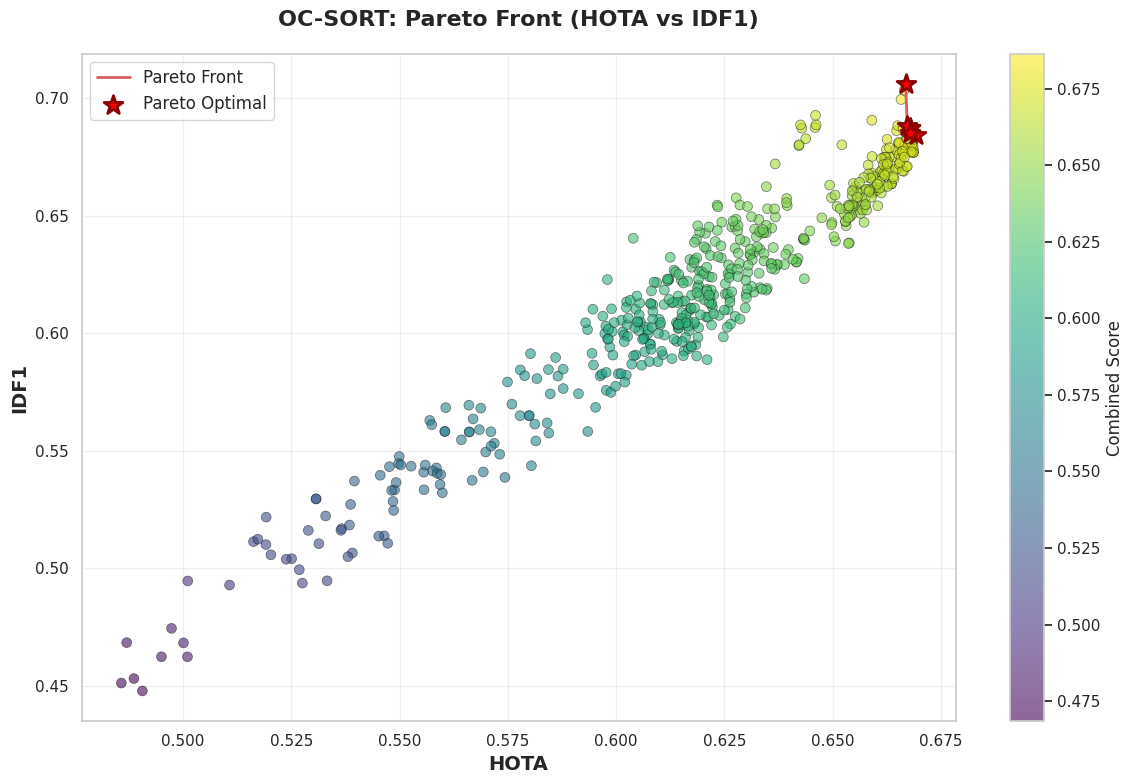

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all trials
scatter = ax.scatter(df_results['HOTA'], df_results['IDF1'], 
                    c=df_results['Combined'], cmap='viridis', 
                    s=50, alpha=0.6, edgecolors='k', linewidth=0.5)

# Highlight Pareto front
pareto_sorted = pareto_trials.sort_values('HOTA')
ax.plot(pareto_sorted['HOTA'], pareto_sorted['IDF1'], 
        'r-', linewidth=2, label='Pareto Front', zorder=5)
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=6)

ax.set_xlabel('HOTA', fontsize=14, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=14, fontweight='bold')
ax.set_title('OC-SORT: Pareto Front (HOTA vs IDF1)', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Combined Score', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Interactive 3D Scatter Plots

In [54]:
# 3D plot: iou_threshold vs max_age vs HOTA
df_results['Pareto'] = df_results['is_pareto'].map({True: 'Pareto Optimal', False: 'Regular'})

fig = go.Figure()

regular = df_results[~df_results['is_pareto']]
fig.add_trace(go.Scatter3d(
    x=regular['iou_threshold'],
    y=regular['max_age'],
    z=regular['HOTA'],
    mode='markers',
    name='Regular (HOTA)',
    marker=dict(size=4, color=regular['HOTA'], colorscale='Blues', opacity=0.5, 
                showscale=True, colorbar=dict(x=1.15, title="HOTA")),
    text=[f"Det: {row['det_thresh']:.2f}<br>Age: {row['max_age']}<br>IoU: {row['iou_threshold']:.2f}<br>Asso: {row['asso_func']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['iou_threshold'],
    y=pareto_trials['max_age'],
    z=pareto_trials['HOTA'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=8, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"Det: {row['det_thresh']:.2f}<br>Age: {row['max_age']}<br>IoU: {row['iou_threshold']:.2f}<br>Asso: {row['asso_func']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: iou_threshold vs max_age vs HOTA',
    scene=dict(xaxis_title='IoU Threshold', yaxis_title='Max Age', zaxis_title='HOTA',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

In [55]:
# 3D plot: inertia vs delta_t vs IDF1
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=regular['inertia'],
    y=regular['delta_t'],
    z=regular['IDF1'],
    mode='markers',
    name='Regular (IDF1)',
    marker=dict(size=4, color=regular['IDF1'], colorscale='Greens', opacity=0.5, 
                showscale=True, colorbar=dict(x=1.15, title="IDF1")),
    text=[f"Inertia: {row['inertia']:.2f}<br>Delta_t: {row['delta_t']}<br>Asso: {row['asso_func']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['inertia'],
    y=pareto_trials['delta_t'],
    z=pareto_trials['IDF1'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=8, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"Inertia: {row['inertia']:.2f}<br>Delta_t: {row['delta_t']}<br>Asso: {row['asso_func']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: inertia vs delta_t vs IDF1',
    scene=dict(xaxis_title='Inertia', yaxis_title='Delta T', zaxis_title='IDF1',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

## 7. Categorical Parameter Analysis

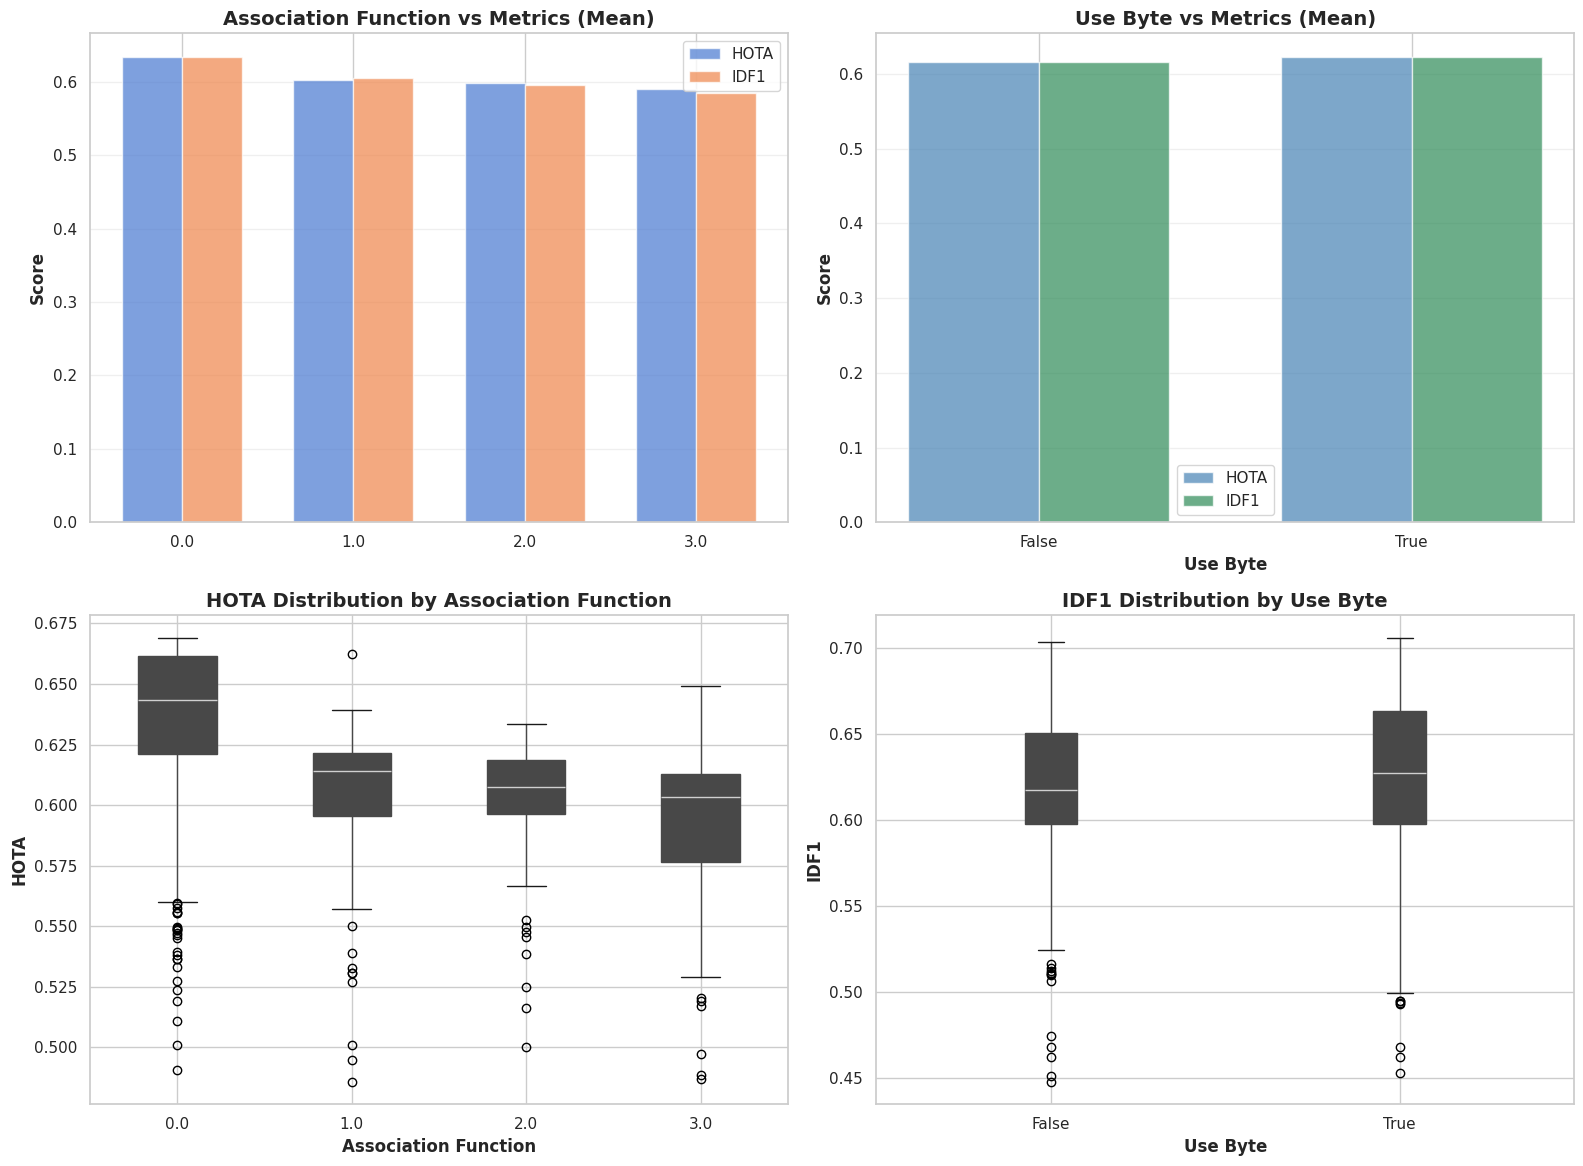

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Association Function effect
ax = axes[0, 0]
asso_means = df_results.groupby('asso_func')[['HOTA', 'IDF1']].mean()
x = range(len(asso_means))
width = 0.35
ax.bar([i - width/2 for i in x], asso_means['HOTA'], width, label='HOTA', alpha=0.7)
ax.bar([i + width/2 for i in x], asso_means['IDF1'], width, label='IDF1', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(asso_means.index)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Association Function vs Metrics (Mean)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Use Byte effect
ax = axes[0, 1]
byte_means = df_results.groupby('use_byte')[['HOTA', 'IDF1']].mean()
x = range(len(byte_means))
ax.bar([i - width/2 for i in x], byte_means['HOTA'], width, label='HOTA', alpha=0.7, color='steelblue')
ax.bar([i + width/2 for i in x], byte_means['IDF1'], width, label='IDF1', alpha=0.7, color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(['False', 'True'])
ax.set_xlabel('Use Byte', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Use Byte vs Metrics (Mean)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Association Function boxplots
ax = axes[1, 0]
df_results.boxplot(column='HOTA', by='asso_func', ax=ax, patch_artist=True)
ax.set_xlabel('Association Function', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('HOTA Distribution by Association Function', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=0)

# Use Byte boxplots
ax = axes[1, 1]
df_results.boxplot(column='IDF1', by='use_byte', ax=ax, patch_artist=True)
ax.set_xlabel('Use Byte', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('IDF1 Distribution by Use Byte', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Numerical Parameters vs Metrics (Separated)

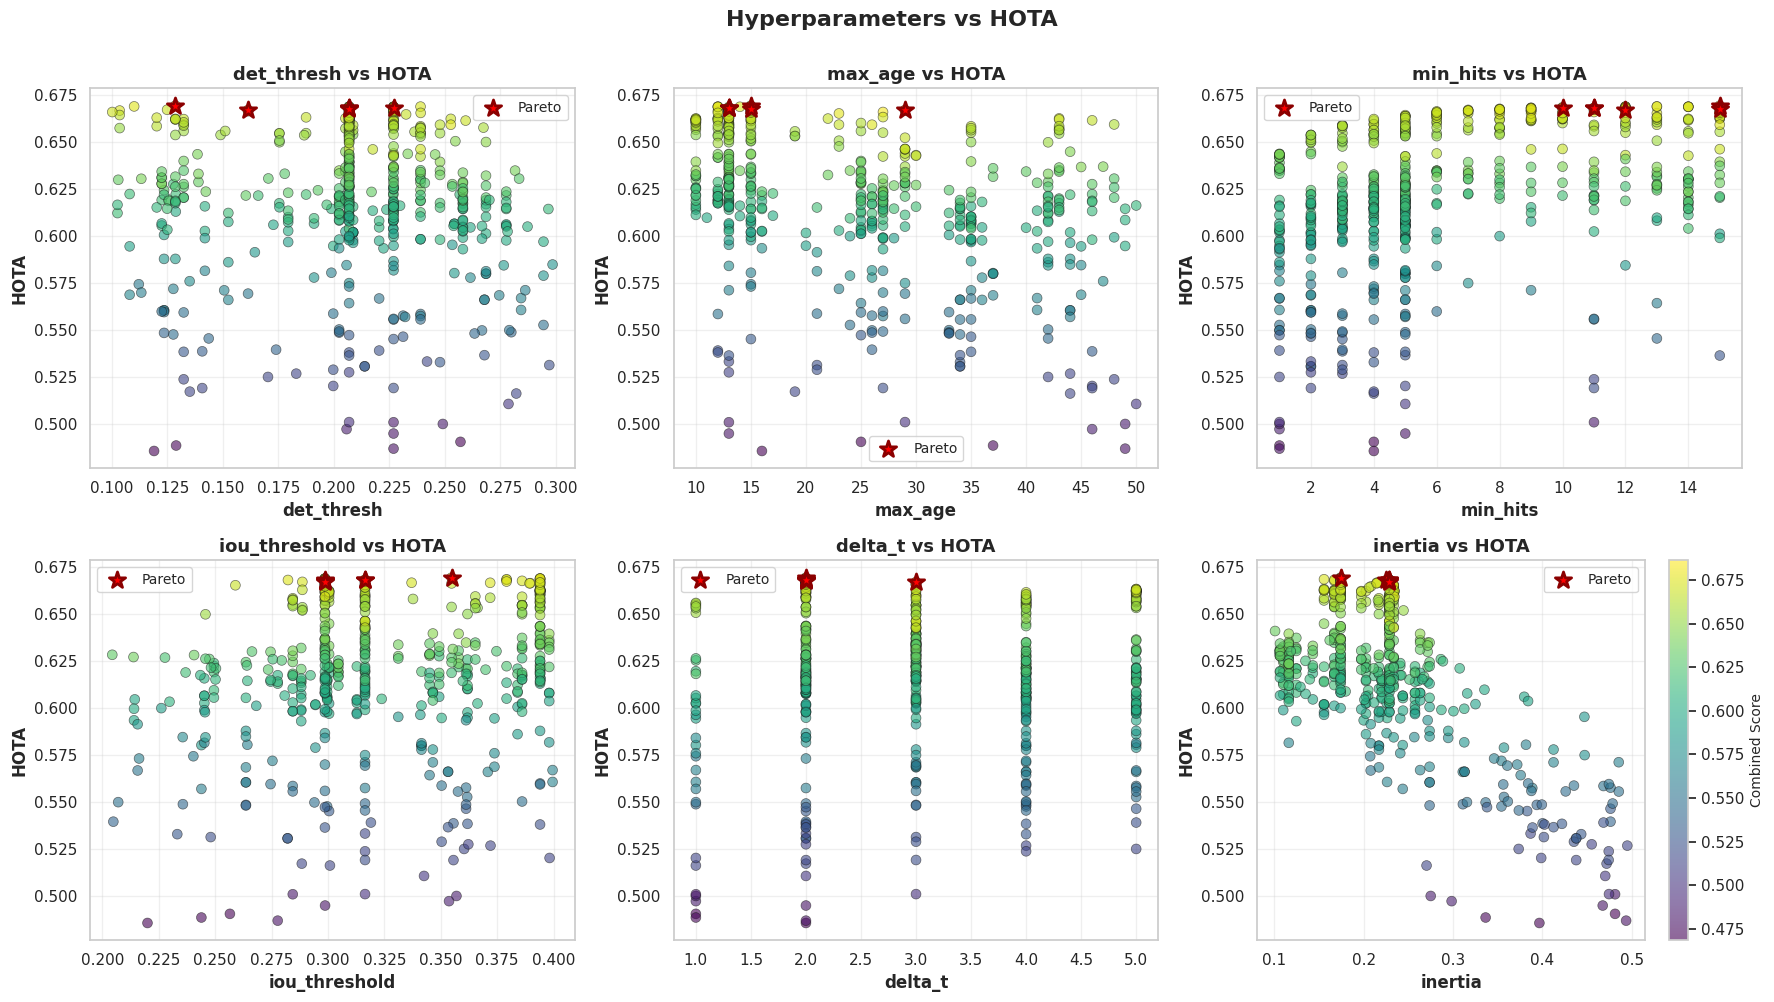

In [57]:
numerical_params = ['det_thresh', 'max_age', 'min_hits', 'iou_threshold', 'delta_t', 'inertia']

# Plot 1: Parameters vs HOTA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, param in enumerate(numerical_params):
    ax = axes[idx]
    scatter = ax.scatter(df_results[param], df_results['HOTA'], 
                        c=df_results['Combined'], cmap='viridis', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.scatter(pareto_trials[param], pareto_trials['HOTA'], 
              c='red', s=150, marker='*', edgecolors='darkred', linewidth=2, label='Pareto', zorder=5)
    ax.set_xlabel(param, fontsize=12, fontweight='bold')
    ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
    ax.set_title(f'{param} vs HOTA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add colorbar only for the last subplot
    if idx == len(numerical_params) - 1:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Combined Score', fontsize=10)

plt.suptitle('Hyperparameters vs HOTA', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

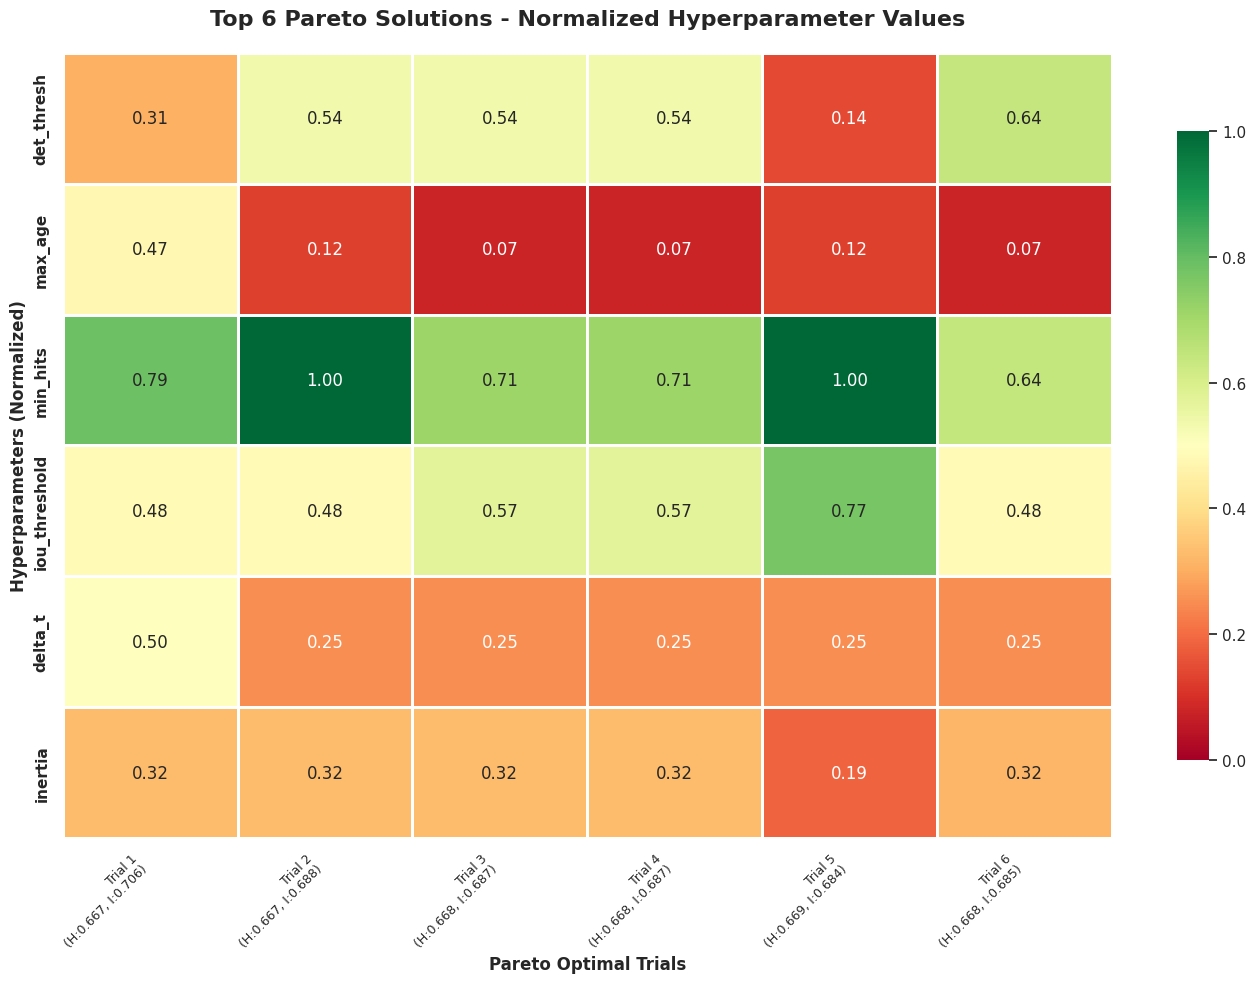

In [58]:
# Heatmap showing normalized hyperparameter values for top Pareto solutions
top_pareto = pareto_trials.nlargest(min(15, len(pareto_trials)), 'Combined')

# Normalize parameters for heatmap
data_for_heatmap = top_pareto[numerical_params].copy()
for param in numerical_params:
    param_min = df_results[param].min()
    param_max = df_results[param].max()
    data_for_heatmap[param] = (top_pareto[param] - param_min) / (param_max - param_min)

# Create labels with metrics
labels = [f"Trial {i+1}\n(H:{row['HOTA']:.3f}, I:{row['IDF1']:.3f})" 
          for i, (_, row) in enumerate(top_pareto.iterrows())]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(data_for_heatmap.T, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0.5, square=False, linewidths=1, cbar_kws={"shrink": 0.8},
            yticklabels=numerical_params, xticklabels=labels,
            vmin=0, vmax=1, ax=ax)

ax.set_xlabel('Pareto Optimal Trials', fontsize=12, fontweight='bold')
ax.set_ylabel('Hyperparameters (Normalized)', fontsize=12, fontweight='bold')
plt.title(f'Top {len(top_pareto)} Pareto Solutions - Normalized Hyperparameter Values', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8c. Hyperparameter Heatmap - Pareto Solutions

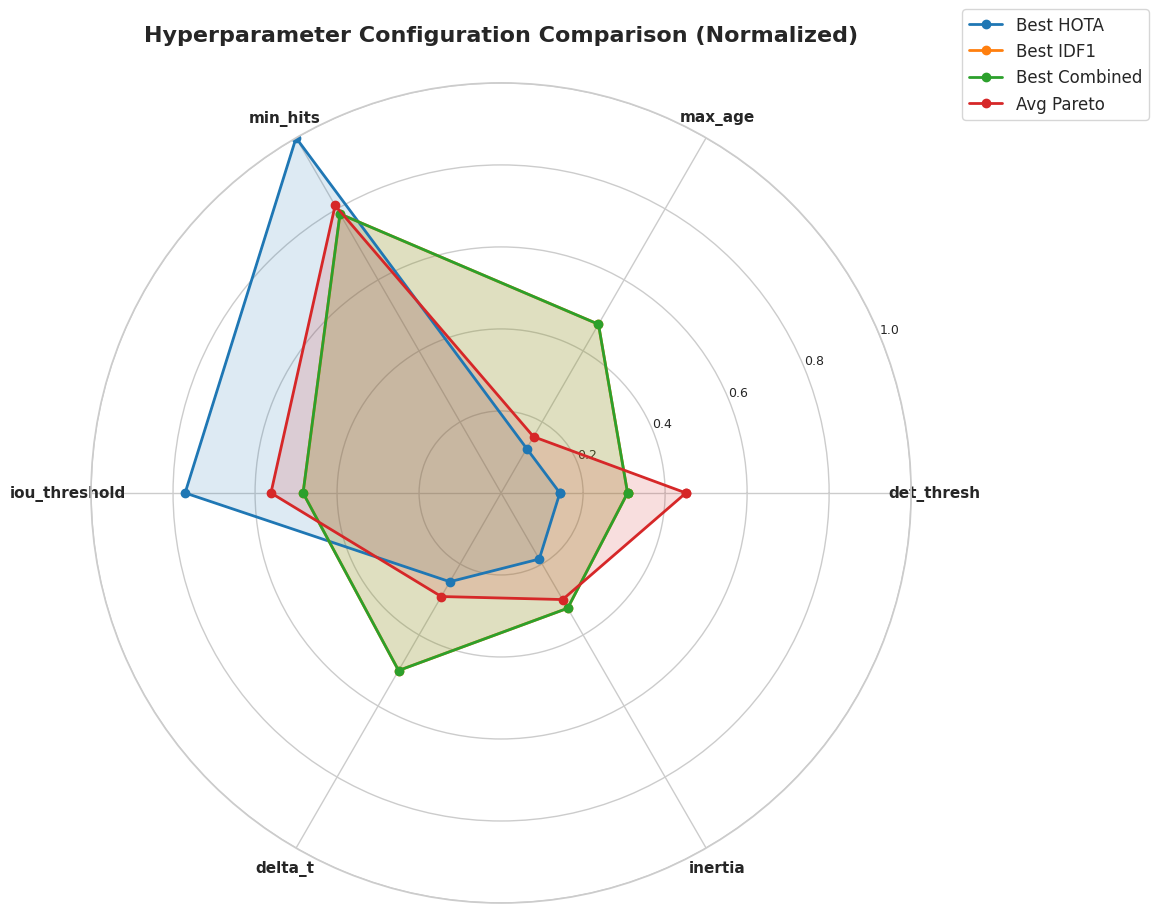

CONFIGURATION VALUES

Best HOTA Configuration (HOTA=0.6692, IDF1=0.6842):
  det_thresh     : 0.1287
  max_age        : 15.0000
  min_hits       : 15.0000
  iou_threshold  : 0.3548
  delta_t        : 2.0000
  inertia        : 0.1742

Best IDF1 Configuration (HOTA=0.6668, IDF1=0.7059):
  det_thresh     : 0.1614
  max_age        : 29.0000
  min_hits       : 12.0000
  iou_threshold  : 0.2987
  delta_t        : 3.0000
  inertia        : 0.2289

Best Combined Configuration (HOTA=0.6668, IDF1=0.7059):
  det_thresh     : 0.1614
  max_age        : 29.0000
  min_hits       : 12.0000
  iou_threshold  : 0.2987
  delta_t        : 3.0000
  inertia        : 0.2289

Average Pareto Configuration:
  det_thresh     : 0.1896
  max_age        : 16.3333
  min_hits       : 12.3333
  iou_threshold  : 0.3139
  delta_t        : 2.1667
  inertia        : 0.2192


In [59]:
# Radar chart comparing best configurations
from math import pi

# Normalize parameters to [0, 1] range for radar chart
def normalize_param(series):
    return (series - series.min()) / (series.max() - series.min())

# Get best configurations
best_hota = df_results.loc[df_results['HOTA'].idxmax()]
best_idf1 = df_results.loc[df_results['IDF1'].idxmax()]
best_combined = df_results.loc[df_results['Combined'].idxmax()]
avg_pareto = pareto_trials[numerical_params].mean()

# Normalize all parameters
df_normalized = df_results.copy()
for param in numerical_params:
    df_normalized[param] = normalize_param(df_results[param])

# Get normalized values for each configuration
configs = {
    'Best HOTA': [normalize_param(df_results[param])[best_hota.name] for param in numerical_params],
    'Best IDF1': [normalize_param(df_results[param])[best_idf1.name] for param in numerical_params],
    'Best Combined': [normalize_param(df_results[param])[best_combined.name] for param in numerical_params],
    'Avg Pareto': [normalize_param(df_results[param]).loc[pareto_trials.index].mean() for param in numerical_params]
}

# Number of variables
categories = numerical_params
N = len(categories)

# Create radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (config_name, values), color in zip(configs.items(), colors):
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=config_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(True)

plt.title('Hyperparameter Configuration Comparison (Normalized)', 
          fontsize=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.show()

# Print actual values for reference
print("="*80)
print("CONFIGURATION VALUES")
print("="*80)
print(f"\nBest HOTA Configuration (HOTA={best_hota['HOTA']:.4f}, IDF1={best_hota['IDF1']:.4f}):")
for param in numerical_params:
    print(f"  {param:15s}: {best_hota[param]:.4f}")

print(f"\nBest IDF1 Configuration (HOTA={best_idf1['HOTA']:.4f}, IDF1={best_idf1['IDF1']:.4f}):")
for param in numerical_params:
    print(f"  {param:15s}: {best_idf1[param]:.4f}")

print(f"\nBest Combined Configuration (HOTA={best_combined['HOTA']:.4f}, IDF1={best_combined['IDF1']:.4f}):")
for param in numerical_params:
    print(f"  {param:15s}: {best_combined[param]:.4f}")

print(f"\nAverage Pareto Configuration:")
for param in numerical_params:
    print(f"  {param:15s}: {avg_pareto[param]:.4f}")

## 8b. Optimal Configuration Comparison - Radar Chart

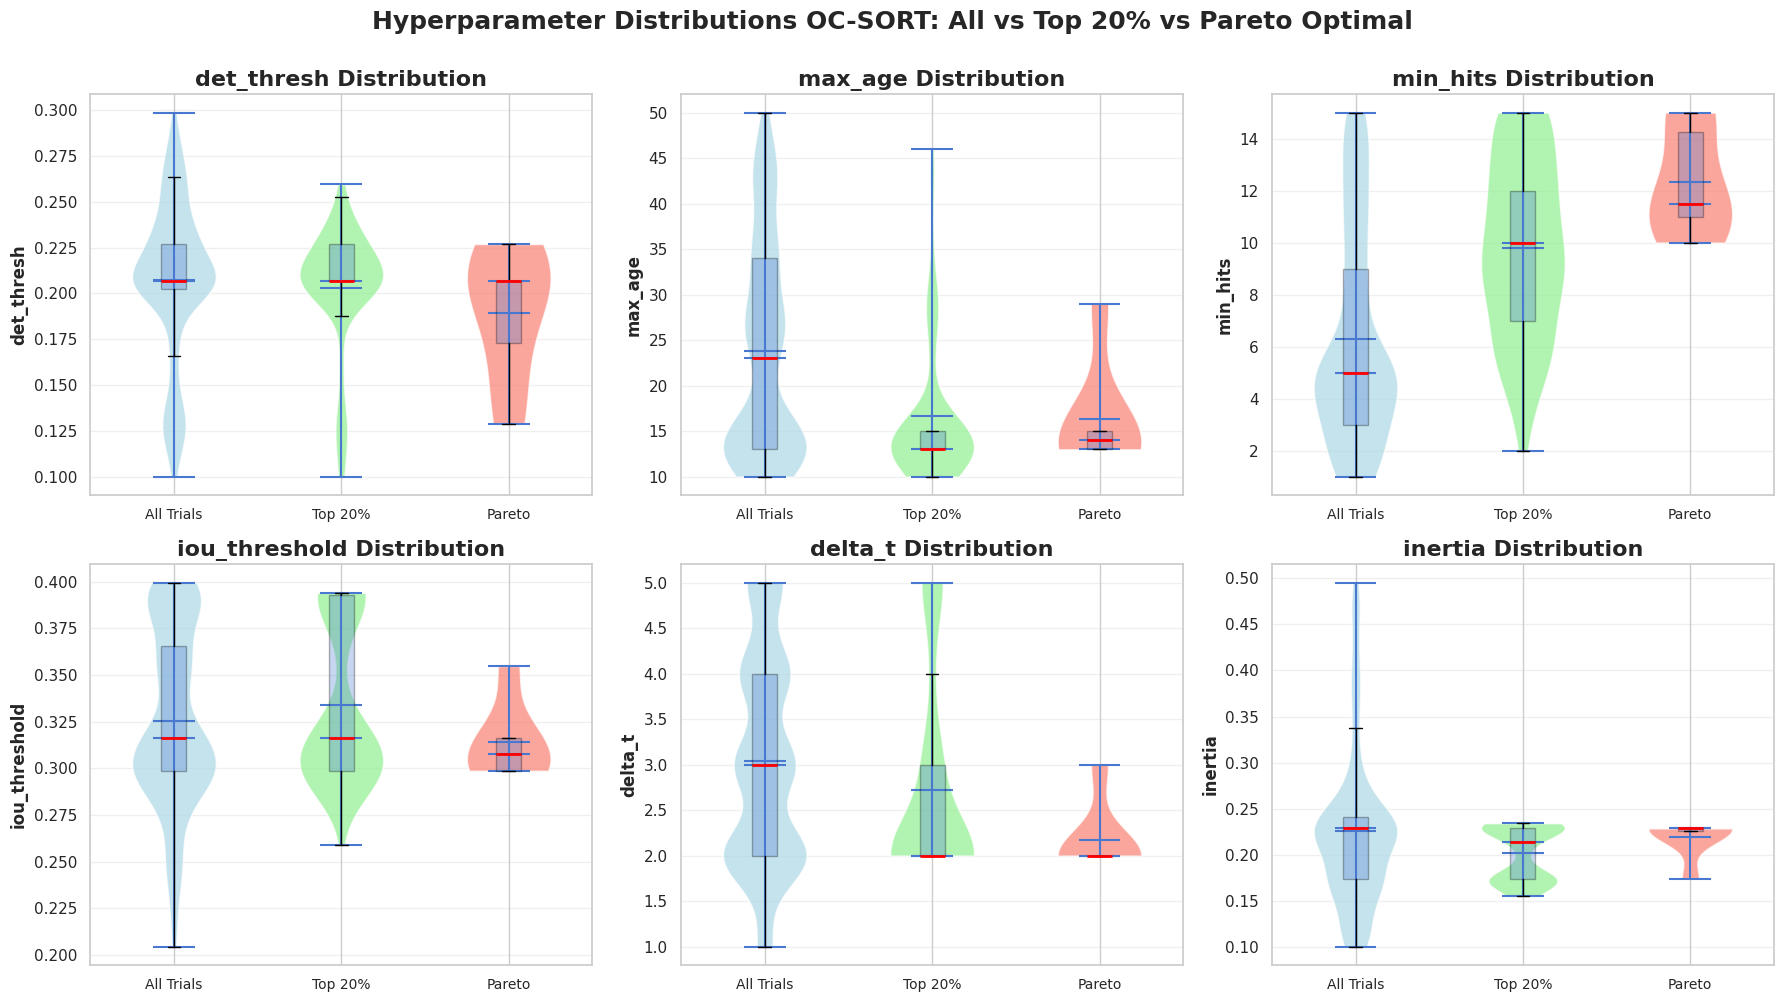

In [71]:
# Violin plots comparing All Trials vs Pareto Optimal vs Top 20% Combined
top_20_pct = df_results.nlargest(int(len(df_results)*0.2), 'Combined')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, param in enumerate(numerical_params):
    ax = axes[idx]
    
    # Prepare data for violin plot
    data_to_plot = [
        df_results[param],
        top_20_pct[param],
        pareto_trials[param]
    ]
    
    positions = [1, 2, 3]
    parts = ax.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True, showextrema=True)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'salmon']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    # Add box plots on top for better readability
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.15, 
                     patch_artist=True, showfliers=False,
                     boxprops=dict(alpha=0.3),
                     medianprops=dict(color='red', linewidth=2))
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['All Trials', 'Top 20%', 'Pareto'], fontsize=10)
    ax.set_ylabel(param, fontsize=12, fontweight='bold')
    ax.set_title(f'{param} Distribution', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Hyperparameter Distributions OC-SORT: All vs Top 20% vs Pareto Optimal', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8a. Optimal Hyperparameter Ranges - Violin Plots

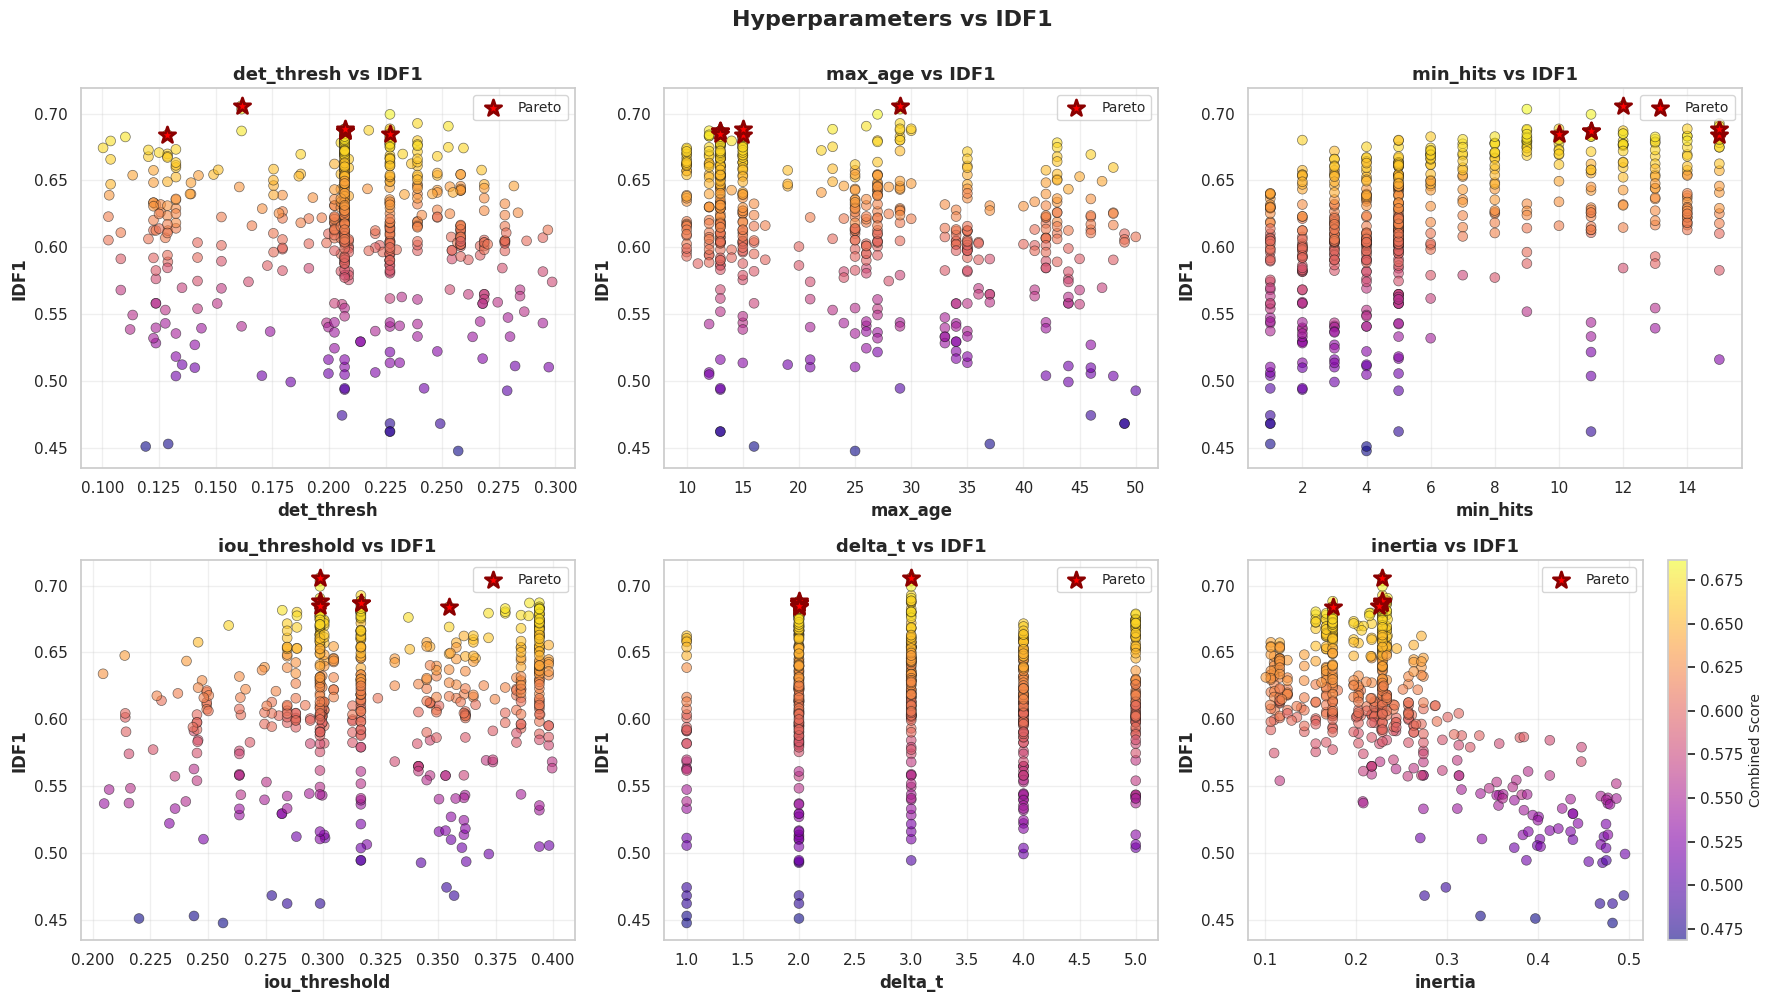

In [61]:
# Plot 2: Parameters vs IDF1
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, param in enumerate(numerical_params):
    ax = axes[idx]
    scatter = ax.scatter(df_results[param], df_results['IDF1'], 
                        c=df_results['Combined'], cmap='plasma', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.scatter(pareto_trials[param], pareto_trials['IDF1'], 
              c='red', s=150, marker='*', edgecolors='darkred', linewidth=2, label='Pareto', zorder=5)
    ax.set_xlabel(param, fontsize=12, fontweight='bold')
    ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
    ax.set_title(f'{param} vs IDF1', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add colorbar only for the last subplot
    if idx == len(numerical_params) - 1:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Combined Score', fontsize=10)

plt.suptitle('Hyperparameters vs IDF1', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

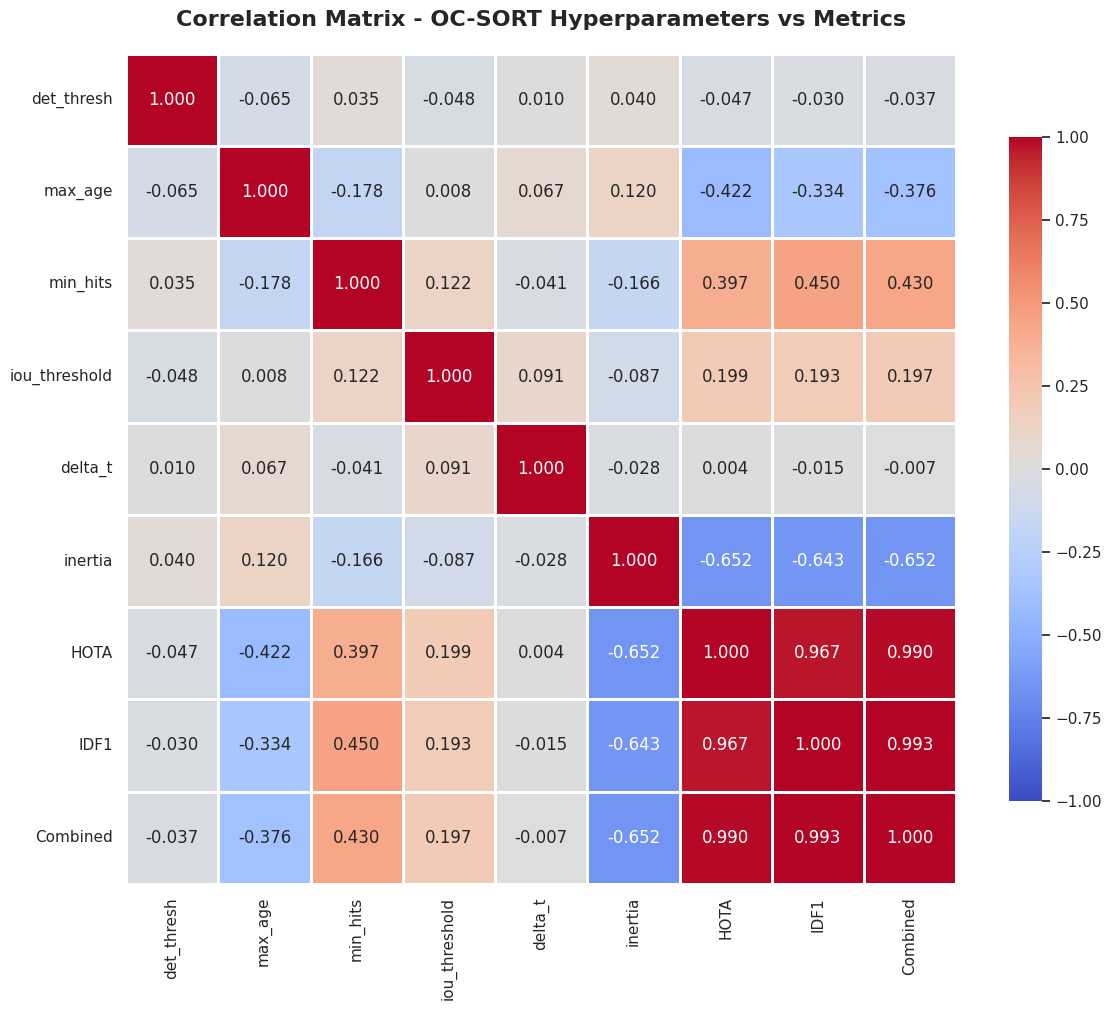


Key correlations with HOTA:
  det_thresh      vs HOTA: -0.0467
  max_age         vs HOTA: -0.4219
  min_hits        vs HOTA:  0.3966
  iou_threshold   vs HOTA:  0.1987
  delta_t         vs HOTA:  0.0040
  inertia         vs HOTA: -0.6523

Key correlations with IDF1:
  det_thresh      vs IDF1: -0.0296
  max_age         vs IDF1: -0.3345
  min_hits        vs IDF1:  0.4502
  iou_threshold   vs IDF1:  0.1931
  delta_t         vs IDF1: -0.0149
  inertia         vs IDF1: -0.6429

HOTA vs IDF1: 0.9669


In [62]:
# Correlation matrix for numerical parameters
correlation_cols = numerical_params + ['HOTA', 'IDF1', 'Combined']
correlation_matrix = df_results[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - OC-SORT Hyperparameters vs Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations with HOTA:")
for param in numerical_params:
    print(f"  {param:15s} vs HOTA: {correlation_matrix.loc[param, 'HOTA']:7.4f}")

print("\nKey correlations with IDF1:")
for param in numerical_params:
    print(f"  {param:15s} vs IDF1: {correlation_matrix.loc[param, 'IDF1']:7.4f}")

print(f"\nHOTA vs IDF1: {correlation_matrix.loc['HOTA', 'IDF1']:.4f}")

## 10. Distribution Analysis

/tmp/ipykernel_67083/2997671096.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



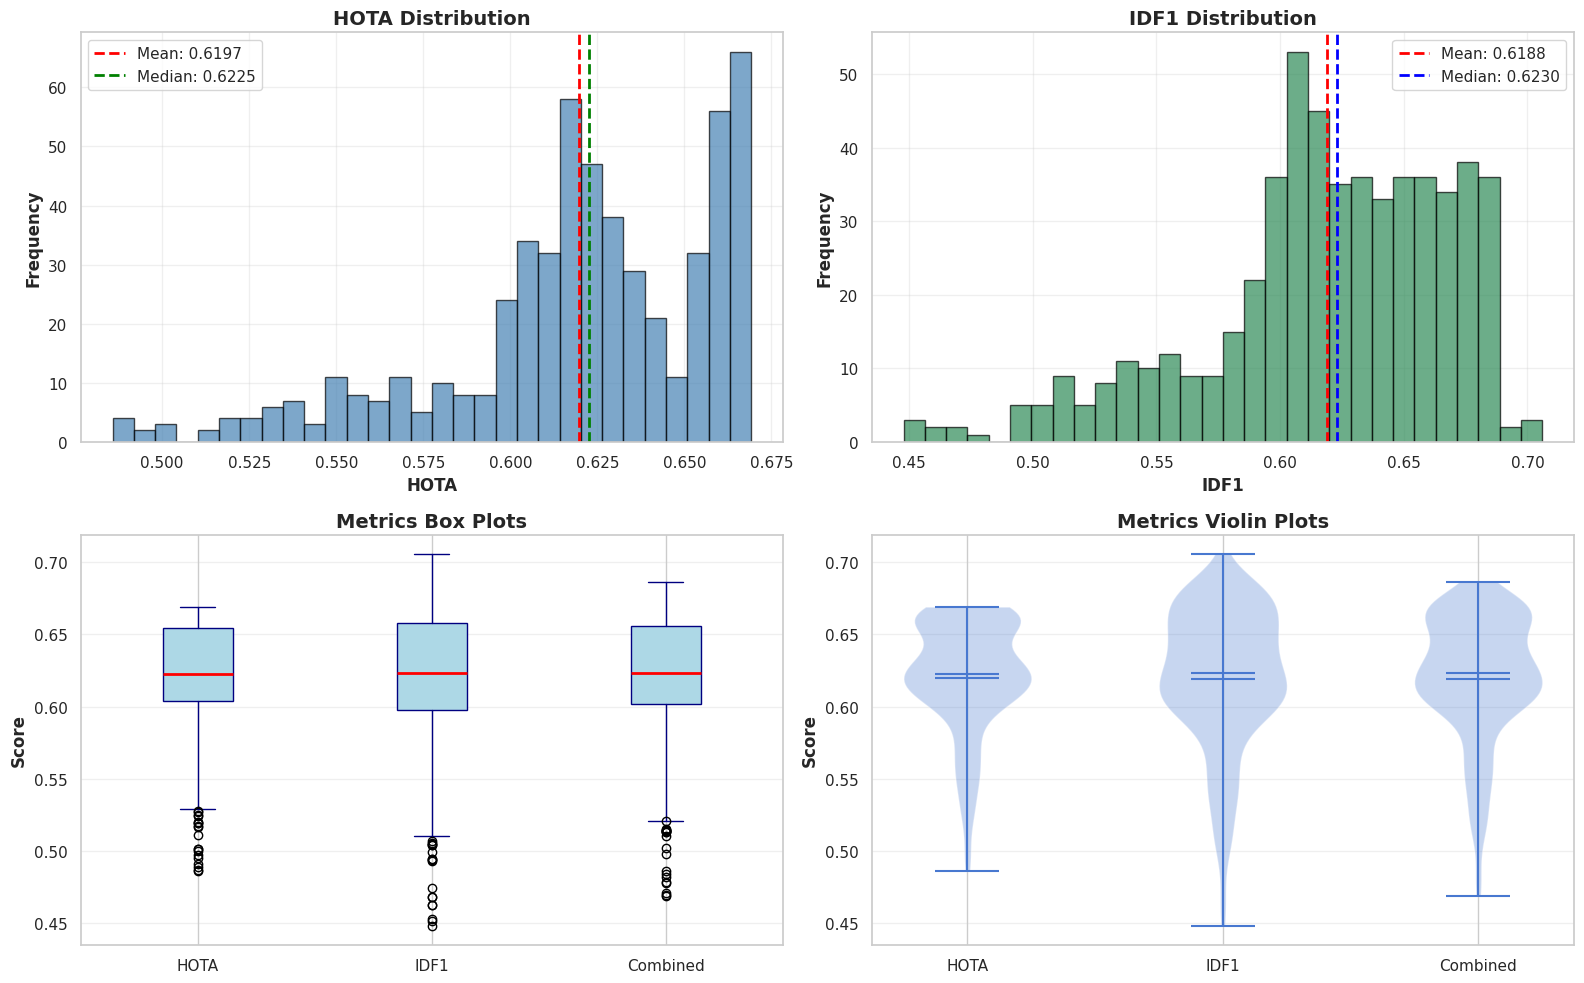

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HOTA distribution
axes[0, 0].hist(df_results['HOTA'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_results['HOTA'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["HOTA"].mean():.4f}')
axes[0, 0].axvline(df_results['HOTA'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["HOTA"].median():.4f}')
axes[0, 0].set_xlabel('HOTA', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('HOTA Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# IDF1 distribution
axes[0, 1].hist(df_results['IDF1'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].axvline(df_results['IDF1'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["IDF1"].mean():.4f}')
axes[0, 1].axvline(df_results['IDF1'].median(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["IDF1"].median():.4f}')
axes[0, 1].set_xlabel('IDF1', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('IDF1 Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plots
box_data = [df_results['HOTA'], df_results['IDF1'], df_results['Combined']]
axes[1, 0].boxplot(box_data, labels=['HOTA', 'IDF1', 'Combined'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
axes[1, 0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Metrics Box Plots', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Violin plots
parts = axes[1, 1].violinplot(box_data, positions=[1, 2, 3], showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_xticklabels(['HOTA', 'IDF1', 'Combined'])
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Metrics Violin Plots', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. Pareto Front Analysis by Categorical Parameters

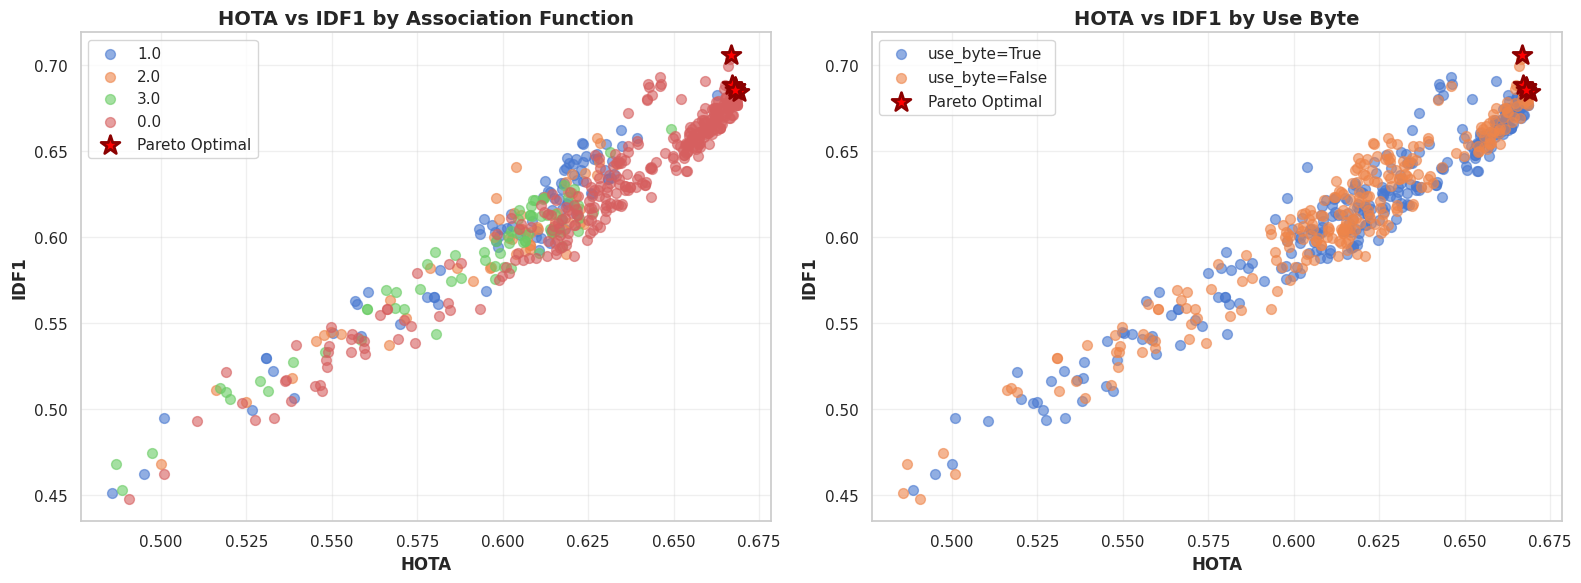

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto trials by association function
ax = axes[0]
for asso in df_results['asso_func'].unique():
    subset = df_results[df_results['asso_func'] == asso]
    ax.scatter(subset['HOTA'], subset['IDF1'], label=asso, alpha=0.6, s=50)

# Highlight Pareto optimal
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=10)

ax.set_xlabel('HOTA', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('HOTA vs IDF1 by Association Function', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Pareto trials by use_byte
ax = axes[1]
for byte_val in df_results['use_byte'].unique():
    subset = df_results[df_results['use_byte'] == byte_val]
    label = f'use_byte={byte_val}'
    ax.scatter(subset['HOTA'], subset['IDF1'], label=label, alpha=0.6, s=50)

# Highlight Pareto optimal
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=10)

ax.set_xlabel('HOTA', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('HOTA vs IDF1 by Use Byte', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Parameter Importance for Pareto Solutions

In [65]:
print("="*80)
print("PARAMETER DISTRIBUTIONS IN PARETO OPTIMAL SOLUTIONS")
print("="*80)

print("\nCategorical Parameters:")
print(f"\nAssociation Function distribution (Pareto):")
print(pareto_trials['asso_func'].value_counts())

print(f"\nUse Byte distribution (Pareto):")
print(pareto_trials['use_byte'].value_counts())

print("\nNumerical Parameters (Pareto trials):")
for param in numerical_params:
    print(f"\n{param}:")
    print(f"  Mean: {pareto_trials[param].mean():.4f}")
    print(f"  Std:  {pareto_trials[param].std():.4f}")
    print(f"  Min:  {pareto_trials[param].min():.4f}")
    print(f"  Max:  {pareto_trials[param].max():.4f}")

PARAMETER DISTRIBUTIONS IN PARETO OPTIMAL SOLUTIONS

Categorical Parameters:

Association Function distribution (Pareto):
asso_func
0.0    6
Name: count, dtype: int64

Use Byte distribution (Pareto):
use_byte
True     5
False    1
Name: count, dtype: int64

Numerical Parameters (Pareto trials):

det_thresh:
  Mean: 0.1896
  Std:  0.0369
  Min:  0.1287
  Max:  0.2269

max_age:
  Mean: 16.3333
  Std:  6.2823
  Min:  13.0000
  Max:  29.0000

min_hits:
  Mean: 12.3333
  Std:  2.1602
  Min:  10.0000
  Max:  15.0000

iou_threshold:
  Mean: 0.3139
  Std:  0.0218
  Min:  0.2987
  Max:  0.3548

delta_t:
  Mean: 2.1667
  Std:  0.4082
  Min:  2.0000
  Max:  3.0000

inertia:
  Mean: 0.2192
  Std:  0.0221
  Min:  0.1742
  Max:  0.2289


## 13. Top Configurations

In [66]:
print("="*80)
print("TOP 10 CONFIGURATIONS")
print("="*80)

display_cols = param_cols + ['HOTA', 'IDF1', 'Combined']

print("\nBy HOTA:")
top_hota = df_results.nlargest(10, 'HOTA')[display_cols]
print(top_hota.to_string(index=False))

print("\n" + "-"*80)
print("\nBy IDF1:")
top_idf1 = df_results.nlargest(10, 'IDF1')[display_cols]
print(top_idf1.to_string(index=False))

print("\n" + "-"*80)
print("\nBy Combined Score:")
top_combined = df_results.nlargest(10, 'Combined')[display_cols]
print(top_combined.to_string(index=False))

TOP 10 CONFIGURATIONS

By HOTA:
 det_thresh  max_age  min_hits  iou_threshold  delta_t  asso_func  inertia  use_byte     HOTA     IDF1  Combined
   0.128684     15.0      15.0       0.354811      2.0        0.0 0.174224      True 0.669177 0.684187  0.676682
   0.110112     15.0      13.0       0.394032      2.0        0.0 0.174224      True 0.668748 0.682502  0.675625
   0.239088     15.0      12.0       0.298658      2.0        0.0 0.174224     False 0.668646 0.676851  0.672748
   0.206926     15.0      12.0       0.298658      2.0        0.0 0.174224      True 0.668646 0.676851  0.672748
   0.226936     15.0      13.0       0.298658      2.0        0.0 0.174224     False 0.668632 0.678009  0.673320
   0.206926     12.0      14.0       0.394032      2.0        0.0 0.174224      True 0.668594 0.683095  0.675844
   0.206926     12.0      14.0       0.394032      2.0        0.0 0.174224      True 0.668594 0.683095  0.675844
   0.226936     14.0      14.0       0.298658      2.0        0.

## 14. Interactive Parallel Coordinates Plot

In [67]:
# Select top trials for cleaner visualization
top_trials = df_results.nlargest(50, 'Combined')

# Prepare data for parallel coordinates
plot_data = top_trials[numerical_params + ['asso_func', 'HOTA', 'IDF1', 'Combined']].copy()

# Encode categorical variable
asso_map = {val: idx for idx, val in enumerate(plot_data['asso_func'].unique())}
plot_data['asso_func_encoded'] = plot_data['asso_func'].map(asso_map)

# Create parallel coordinates plot
dimensions = []

for param in numerical_params:
    dimensions.append(dict(
        range=[plot_data[param].min(), plot_data[param].max()],
        label=param,
        values=plot_data[param]
    ))

dimensions.append(dict(
    range=[0, len(asso_map)-1],
    label='asso_func',
    values=plot_data['asso_func_encoded'],
    tickvals=list(asso_map.values()),
    ticktext=list(asso_map.keys())
))

dimensions.append(dict(
    range=[plot_data['HOTA'].min(), plot_data['HOTA'].max()],
    label='HOTA',
    values=plot_data['HOTA']
))

dimensions.append(dict(
    range=[plot_data['IDF1'].min(), plot_data['IDF1'].max()],
    label='IDF1',
    values=plot_data['IDF1']
))

fig = go.Figure(data=go.Parcoords(
    line=dict(color=plot_data['Combined'],
              colorscale='Viridis',
              showscale=True,
              cmin=plot_data['Combined'].min(),
              cmax=plot_data['Combined'].max()),
    dimensions=dimensions
))

fig.update_layout(
    title='Parallel Coordinates Plot - Top 50 Trials by Combined Score',
    width=1200,
    height=600
)

fig.show()

## 15. Summary and Recommendations

In [68]:
print("="*80)
print("OC-SORT - SUMMARY AND RECOMMENDATIONS")
print("="*80)

best_combined_trial = df_results.loc[df_results['Combined'].idxmax()]

print("\n🏆 RECOMMENDED CONFIGURATION (Best Combined Score):")
print(f"  - Detection Threshold: {best_combined_trial['det_thresh']:.4f}")
print(f"  - Max Age: {int(best_combined_trial['max_age'])}")
print(f"  - Min Hits: {int(best_combined_trial['min_hits'])}")
print(f"  - IoU Threshold: {best_combined_trial['iou_threshold']:.4f}")
print(f"  - Delta T: {int(best_combined_trial['delta_t'])}")
print(f"  - Association Function: {best_combined_trial['asso_func']}")
print(f"  - Inertia: {best_combined_trial['inertia']:.4f}")
print(f"  - Use Byte: {best_combined_trial['use_byte']}")
print(f"  - HOTA: {best_combined_trial['HOTA']:.4f}")
print(f"  - IDF1: {best_combined_trial['IDF1']:.4f}")
print(f"  - Combined: {best_combined_trial['Combined']:.4f}")

print("\n📊 Key Findings:")
print(f"  • Total trials evaluated: {len(df_results)}")
print(f"  • Pareto optimal solutions: {len(pareto_trials)}")
print(f"  • HOTA range: [{df_results['HOTA'].min():.4f}, {df_results['HOTA'].max():.4f}]")
print(f"  • IDF1 range: [{df_results['IDF1'].min():.4f}, {df_results['IDF1'].max():.4f}]")

print("\n🔍 Parameter Insights (Top 20%):")
hota_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'HOTA')
idf1_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'IDF1')

for param in numerical_params:
    print(f"  • Best {param} range (top 20% HOTA): [{hota_top20_pct[param].min():.2f}, {hota_top20_pct[param].max():.2f}]")

print(f"\n  • Most common asso_func (top 20% HOTA): {hota_top20_pct['asso_func'].mode()[0]}")
print(f"  • Most common use_byte (top 20% HOTA): {hota_top20_pct['use_byte'].mode()[0]}")

print("\n✅ Analysis Complete!")

OC-SORT - SUMMARY AND RECOMMENDATIONS

🏆 RECOMMENDED CONFIGURATION (Best Combined Score):
  - Detection Threshold: 0.1614
  - Max Age: 29
  - Min Hits: 12
  - IoU Threshold: 0.2987
  - Delta T: 3
  - Association Function: 0.0
  - Inertia: 0.2289
  - Use Byte: True
  - HOTA: 0.6668
  - IDF1: 0.7059
  - Combined: 0.6864

📊 Key Findings:
  • Total trials evaluated: 551
  • Pareto optimal solutions: 6
  • HOTA range: [0.4857, 0.6692]
  • IDF1 range: [0.4477, 0.7059]

🔍 Parameter Insights (Top 20%):
  • Best det_thresh range (top 20% HOTA): [0.10, 0.26]
  • Best max_age range (top 20% HOTA): [10.00, 48.00]
  • Best min_hits range (top 20% HOTA): [3.00, 15.00]
  • Best iou_threshold range (top 20% HOTA): [0.26, 0.39]
  • Best delta_t range (top 20% HOTA): [2.00, 5.00]
  • Best inertia range (top 20% HOTA): [0.16, 0.23]

  • Most common asso_func (top 20% HOTA): 0.0
  • Most common use_byte (top 20% HOTA): True

✅ Analysis Complete!
